# DuckDB vs Exp1 Parallelism Comparison

This notebook compares the performance of DuckDB external sorting with the Exp1 lineitem benchmark at different thread counts.

In [7]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Parse DuckDB Log Files

In [8]:
def parse_duckdb_log(filepath):
    """Parse a DuckDB log file to extract thread count and timing."""
    with open(filepath, 'r') as f:
        content = f.read()
    
    # Extract thread count from configuration line
    thread_match = re.search(r'threads=(\d+)', content)
    if not thread_match:
        return None
    threads = int(thread_match.group(1))
    
    # Extract timing
    timing_match = re.search(r'TIMING: ([\d.]+)', content)
    if not timing_match:
        return None
    time_seconds = float(timing_match.group(1))
    
    return {'threads': threads, 'time_seconds': time_seconds}

# Parse all DuckDB log files in the current directory
log_dir = '.'
duckdb_results = []

for filename in os.listdir(log_dir):
    if filename.endswith('.log'):
        filepath = os.path.join(log_dir, filename)
        result = parse_duckdb_log(filepath)
        if result:
            duckdb_results.append(result)

# Create DataFrame and sort by thread count
df_duckdb = pd.DataFrame(duckdb_results)
df_duckdb = df_duckdb.sort_values('threads')
df_duckdb['time_minutes'] = df_duckdb['time_seconds'] / 60

print(f"Found {len(df_duckdb)} DuckDB log files")
print("\nDuckDB Data:")
print(df_duckdb)

Found 7 DuckDB log files

DuckDB Data:
   threads  time_seconds  time_minutes
2        4       5404.72     90.078667
5        8       4006.20     66.770000
0       16       3492.15     58.202500
3       24       3071.22     51.187000
4       32       2570.21     42.836833
1       40       2341.31     39.021833
6       44       2226.09     37.101500


## Parse Exp1 Log Files

In [9]:
def parse_exp1_log(filepath):
    """Parse an Exp1 log file to extract thread counts and timing."""
    filename = os.path.basename(filepath)
    
    # Parse filename: Exp1.1_RunGen40_Merge16_Mem2GB.log or Exp1.2_RunGen16_Merge40_Mem2GB.log
    exp_match = re.search(r'Exp(\d+\.\d+)_RunGen(\d+)_Merge(\d+)', filename)
    if not exp_match:
        return None
    
    exp_num = exp_match.group(1)
    rungen_threads = int(exp_match.group(2))
    merge_threads = int(exp_match.group(3))
    
    with open(filepath, 'r') as f:
        content = f.read()
    
    # Extract average times from the summary table
    # Look for the [avg] line in the summary
    avg_match = re.search(r'\[avg\].*?(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)', content)
    if not avg_match:
        return None
    
    total_time = float(avg_match.group(1))
    rungen_time = float(avg_match.group(2))
    merge_time = float(avg_match.group(3))
    
    return {
        'exp': exp_num,
        'rungen_threads': rungen_threads,
        'merge_threads': merge_threads,
        'total_threads': rungen_threads + merge_threads,  # Combined thread count
        'total_time': total_time,
        'rungen_time': rungen_time,
        'merge_time': merge_time
    }

# Parse Exp1 log files from the lineitem result directory
exp1_log_dir = '../../lineitem/result'
exp1_results = []

if os.path.exists(exp1_log_dir):
    for filename in os.listdir(exp1_log_dir):
        if filename.startswith('Exp1.') and filename.endswith('.log'):
            filepath = os.path.join(exp1_log_dir, filename)
            result = parse_exp1_log(filepath)
            if result:
                exp1_results.append(result)

# Create DataFrame
df_exp1 = pd.DataFrame(exp1_results)

# Split into Exp1.1 and Exp1.2
df_exp1_1 = df_exp1[df_exp1['exp'] == '1.1'].sort_values('merge_threads').copy()
df_exp1_2 = df_exp1[df_exp1['exp'] == '1.2'].sort_values('rungen_threads').copy()

print(f"\nFound {len(df_exp1)} Exp1 log files")
print("\nExp1.1 Data (Fixed RunGen=40, Varying Merge):")
print(df_exp1_1[['rungen_threads', 'merge_threads', 'total_time', 'rungen_time', 'merge_time']])
print("\nExp1.2 Data (Fixed Merge=40, Varying RunGen):")
print(df_exp1_2[['rungen_threads', 'merge_threads', 'total_time', 'rungen_time', 'merge_time']])


Found 12 Exp1 log files

Exp1.1 Data (Fixed RunGen=40, Varying Merge):
    rungen_threads  merge_threads  total_time  rungen_time  merge_time
5               40              4     1025.73       356.09      669.64
11              40              8      797.22       355.33      441.88
2               40             16      675.68       364.35      311.33
6               40             24      672.33       361.73      310.60
1               40             32      679.36       356.20      323.17
7               40             40      693.00       364.98      328.02

Exp1.2 Data (Fixed Merge=40, Varying RunGen):
    rungen_threads  merge_threads  total_time  rungen_time  merge_time
3                4             40     1894.42      1554.42      339.99
8                8             40     1187.40       861.33      326.07
0               16             40      873.34       548.43      324.91
10              24             40      774.38       448.30      326.08
9               32           

## Plot 1: DuckDB vs Exp1.1 - Time vs Threads

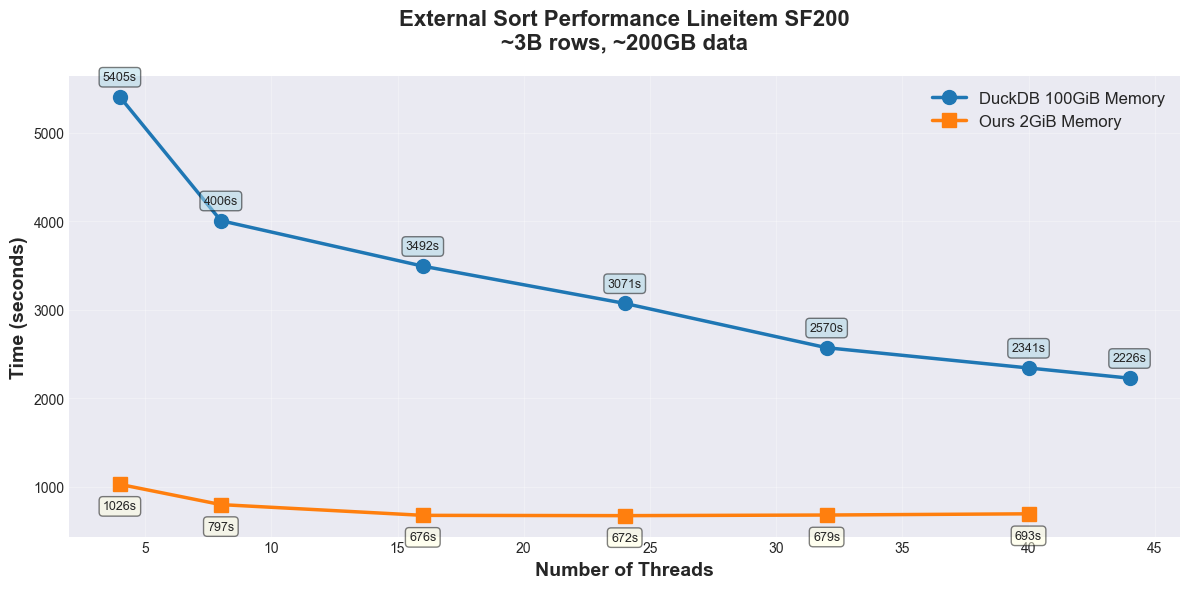

In [16]:
fig, ax = plt.subplots()

# Plot DuckDB data
ax.plot(df_duckdb['threads'], df_duckdb['time_seconds'], 
        marker='o', linewidth=2.5, markersize=10, label='DuckDB 100GiB Memory', color='#1f77b4')

# Plot Exp1.1 data (varying merge threads)
if len(df_exp1_1) > 0:
    ax.plot(df_exp1_1['merge_threads'], df_exp1_1['total_time'], 
            marker='s', linewidth=2.5, markersize=10, label='Ours 2GiB Memory', color='#ff7f0e')

ax.set_xlabel('Number of Threads', fontsize=14, fontweight='bold')
ax.set_ylabel('Time (seconds)', fontsize=14, fontweight='bold')
ax.set_title('External Sort Performance Lineitem SF200\n~3B rows, ~200GB data', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12, loc='best')

# Add value labels for DuckDB
for _, row in df_duckdb.iterrows():
    ax.annotate(f"{row['time_seconds']:.0f}s", 
                xy=(row['threads'], row['time_seconds']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=9, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.5))

# Add value labels for Exp1.1
if len(df_exp1_1) > 0:
    for _, row in df_exp1_1.iterrows():
        ax.annotate(f"{row['total_time']:.0f}s", 
                    xy=(row['merge_threads'], row['total_time']),
                    xytext=(0, -18), textcoords='offset points',
                    ha='center', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.5))

plt.tight_layout()
plt.savefig('duckdb_vs_exp1_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Plot 2: Phase Breakdown Comparison

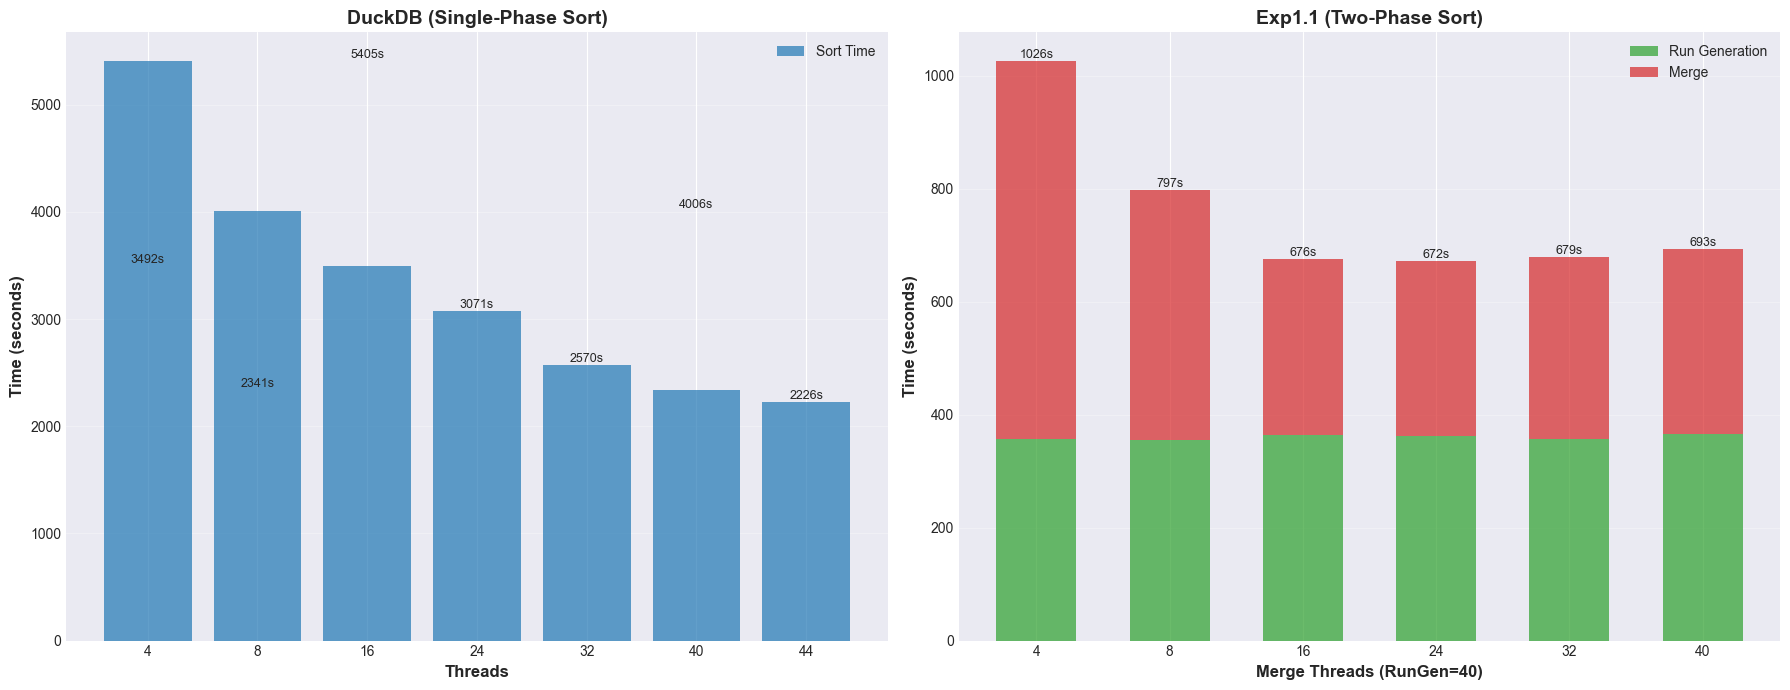

In [11]:
if len(df_exp1_1) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    # Left plot: DuckDB (single phase)
    ax1.bar(df_duckdb['threads'].astype(str), df_duckdb['time_seconds'], 
            color='#1f77b4', alpha=0.7, label='Sort Time')
    ax1.set_xlabel('Threads', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
    ax1.set_title('DuckDB (Single-Phase Sort)', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.legend(fontsize=10)
    
    # Add value labels
    for i, row in df_duckdb.iterrows():
        ax1.text(i, row['time_seconds'], f"{row['time_seconds']:.0f}s",
                ha='center', va='bottom', fontsize=9)
    
    # Right plot: Exp1.1 (two phases)
    x_pos = np.arange(len(df_exp1_1))
    width = 0.6
    
    ax2.bar(x_pos, df_exp1_1['rungen_time'], width, 
            label='Run Generation', color='#2ca02c', alpha=0.7)
    ax2.bar(x_pos, df_exp1_1['merge_time'], width, 
            bottom=df_exp1_1['rungen_time'], label='Merge', color='#d62728', alpha=0.7)
    
    ax2.set_xlabel('Merge Threads (RunGen=40)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
    ax2.set_title('Exp1.1 (Two-Phase Sort)', fontsize=14, fontweight='bold')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(df_exp1_1['merge_threads'].astype(str))
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.legend(fontsize=10)
    
    # Add total time labels on top
    for i, row in enumerate(df_exp1_1.itertuples()):
        ax2.text(i, row.total_time, f"{row.total_time:.0f}s",
                ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('duckdb_vs_exp1_phase_breakdown.png', dpi=300, bbox_inches='tight')
    plt.show()

## Plot 3: All Configurations on One Plot

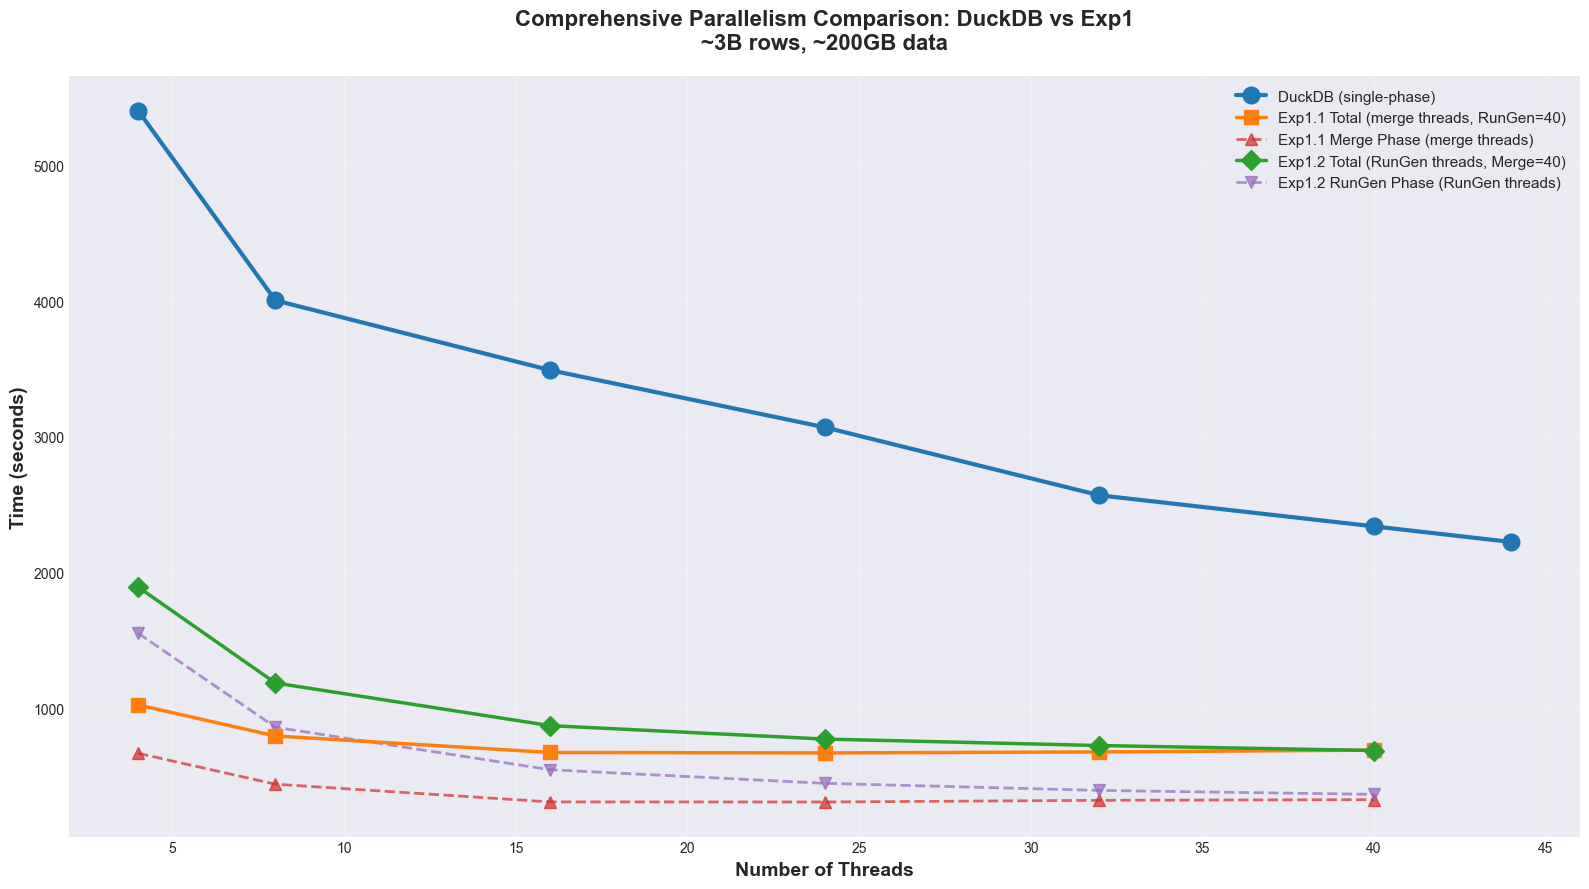

In [12]:
fig, ax = plt.subplots(figsize=(16, 9))

# Plot DuckDB data
ax.plot(df_duckdb['threads'], df_duckdb['time_seconds'], 
        marker='o', linewidth=3, markersize=12, label='DuckDB (single-phase)', 
        color='#1f77b4', zorder=3)

# Plot Exp1.1 data (varying merge threads, fixed RunGen=40)
if len(df_exp1_1) > 0:
    ax.plot(df_exp1_1['merge_threads'], df_exp1_1['total_time'], 
            marker='s', linewidth=2.5, markersize=10, 
            label='Exp1.1 Total (merge threads, RunGen=40)', 
            color='#ff7f0e', linestyle='-', zorder=2)
    ax.plot(df_exp1_1['merge_threads'], df_exp1_1['merge_time'], 
            marker='^', linewidth=2, markersize=8, 
            label='Exp1.1 Merge Phase (merge threads)', 
            color='#d62728', linestyle='--', alpha=0.7, zorder=1)

# Plot Exp1.2 data (varying RunGen threads, fixed Merge=40)
if len(df_exp1_2) > 0:
    ax.plot(df_exp1_2['rungen_threads'], df_exp1_2['total_time'], 
            marker='D', linewidth=2.5, markersize=10, 
            label='Exp1.2 Total (RunGen threads, Merge=40)', 
            color='#2ca02c', linestyle='-', zorder=2)
    ax.plot(df_exp1_2['rungen_threads'], df_exp1_2['rungen_time'], 
            marker='v', linewidth=2, markersize=8, 
            label='Exp1.2 RunGen Phase (RunGen threads)', 
            color='#9467bd', linestyle='--', alpha=0.7, zorder=1)

ax.set_xlabel('Number of Threads', fontsize=14, fontweight='bold')
ax.set_ylabel('Time (seconds)', fontsize=14, fontweight='bold')
ax.set_title('Comprehensive Parallelism Comparison: DuckDB vs Exp1\n~3B rows, ~200GB data', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='best', framealpha=0.9)

plt.tight_layout()
plt.savefig('duckdb_vs_exp1_comprehensive.png', dpi=300, bbox_inches='tight')
plt.show()

## Performance Statistics and Comparison

In [13]:
print("\n" + "="*80)
print("DUCKDB PERFORMANCE SUMMARY")
print("="*80)
print(df_duckdb[['threads', 'time_seconds', 'time_minutes']].to_string(index=False))

if len(df_exp1_1) > 0:
    print("\n" + "="*80)
    print("EXP1.1 PERFORMANCE SUMMARY (Fixed RunGen=40, Varying Merge Threads)")
    print("="*80)
    print(df_exp1_1[['merge_threads', 'total_time', 'rungen_time', 'merge_time']].to_string(index=False))

if len(df_exp1_2) > 0:
    print("\n" + "="*80)
    print("EXP1.2 PERFORMANCE SUMMARY (Fixed Merge=40, Varying RunGen Threads)")
    print("="*80)
    print(df_exp1_2[['rungen_threads', 'total_time', 'rungen_time', 'merge_time']].to_string(index=False))

# Performance comparison at common thread counts
print("\n" + "="*80)
print("PERFORMANCE COMPARISON AT COMMON THREAD COUNTS")
print("="*80)

common_threads = [4, 8, 16, 24, 32, 40]
comparison_data = []

for t in common_threads:
    row = {'threads': t}
    
    # DuckDB
    duckdb_row = df_duckdb[df_duckdb['threads'] == t]
    if len(duckdb_row) > 0:
        row['duckdb_time'] = duckdb_row.iloc[0]['time_seconds']
    else:
        row['duckdb_time'] = None
    
    # Exp1.1 (merge threads)
    exp1_1_row = df_exp1_1[df_exp1_1['merge_threads'] == t]
    if len(exp1_1_row) > 0:
        row['exp1_1_time'] = exp1_1_row.iloc[0]['total_time']
        row['exp1_1_merge'] = exp1_1_row.iloc[0]['merge_time']
    else:
        row['exp1_1_time'] = None
        row['exp1_1_merge'] = None
    
    # Exp1.2 (rungen threads)
    exp1_2_row = df_exp1_2[df_exp1_2['rungen_threads'] == t]
    if len(exp1_2_row) > 0:
        row['exp1_2_time'] = exp1_2_row.iloc[0]['total_time']
        row['exp1_2_rungen'] = exp1_2_row.iloc[0]['rungen_time']
    else:
        row['exp1_2_time'] = None
        row['exp1_2_rungen'] = None
    
    comparison_data.append(row)

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

# Calculate speedup ratios where both exist
print("\n" + "="*80)
print("SPEEDUP COMPARISON (DuckDB baseline)")
print("="*80)
for _, row in df_comparison.iterrows():
    if row['duckdb_time'] and row['exp1_1_time']:
        ratio = row['duckdb_time'] / row['exp1_1_time']
        faster = "DuckDB" if ratio > 1 else "Exp1.1"
        print(f"  {row['threads']:2.0f} threads: DuckDB={row['duckdb_time']:.0f}s, Exp1.1={row['exp1_1_time']:.0f}s, {faster} is {abs(1-ratio)*100:.1f}% faster")


DUCKDB PERFORMANCE SUMMARY
 threads  time_seconds  time_minutes
       4       5404.72     90.078667
       8       4006.20     66.770000
      16       3492.15     58.202500
      24       3071.22     51.187000
      32       2570.21     42.836833
      40       2341.31     39.021833
      44       2226.09     37.101500

EXP1.1 PERFORMANCE SUMMARY (Fixed RunGen=40, Varying Merge Threads)
 merge_threads  total_time  rungen_time  merge_time
             4     1025.73       356.09      669.64
             8      797.22       355.33      441.88
            16      675.68       364.35      311.33
            24      672.33       361.73      310.60
            32      679.36       356.20      323.17
            40      693.00       364.98      328.02

EXP1.2 PERFORMANCE SUMMARY (Fixed Merge=40, Varying RunGen Threads)
 rungen_threads  total_time  rungen_time  merge_time
              4     1894.42      1554.42      339.99
              8     1187.40       861.33      326.07
             16

## Key Observations

This analysis compares:
1. **DuckDB**: Single-phase external sort with varying total thread count
2. **Exp1.1**: Two-phase sort (fixed 40 RunGen threads, varying merge threads)
3. **Exp1.2**: Two-phase sort (varying RunGen threads, fixed 40 merge threads)

Key questions to explore:
- How does DuckDB's single-phase approach compare to the two-phase Exp1 approach?
- Which phase in Exp1 benefits more from additional threads?
- What are the optimal thread configurations for each approach?